# 📘 SISTEM BERBASIS PENGETAHUAN  
## BAB 5: TEOREMA BAYES  

### Studi Kasus: Rekomendasi Tempat Wisata Bali  

---

## 👤 Identitas Kelompok

| No | Nama | NIM | Kelas |
|----|------|------|-------|
| 1 |  | |  |
| 2 | DINI ELMININGTYAS RAHAYU WILUJENG | 2341760180 | D4 Sistem Informasi Bisnis |
| 3 |  |  |  |
| 4 |  |  |  |
| 5 | MUHAMMAD ULIL FAHMI MA'RIFATULLOH | 2341760194 | D4 Sistem Informasi Bisnis  |

---

## 🎯 TUJUAN PRAKTIKUM

1. Memahami konsep **Teorema Bayes**  
2. Menghitung probabilitas suatu hipotesis berdasarkan evidence  
3. Mengimplementasikan Teorema Bayes dalam sistem rekomendasi wisata  
4. Menentukan rekomendasi tempat wisata berdasarkan probabilitas tertinggi  

---

## ⚙️ METODE

Metode yang digunakan adalah **Teorema Bayes**, yaitu pendekatan probabilistik untuk menentukan kemungkinan suatu hipotesis berdasarkan evidence yang tersedia.

Langkah-langkah:
1. Menentukan **hipotesis (H)**  
   - Contoh: jenis wisata (alam, budaya, buatan, dll)

2. Menentukan **evidence (E)**  
   - Contoh: preferensi pengguna (rating tinggi, lokasi, kategori)

3. Menentukan **probabilitas prior (P(H))**  
   - Berdasarkan distribusi data pada dataset wisata Bali

4. Menentukan **likelihood (P(E|H))**  
   - Probabilitas munculnya evidence pada setiap hipotesis

5. Menghitung **probabilitas posterior (P(H|E))**  
   - Menggunakan rumus Teorema Bayes

6. Menentukan hasil rekomendasi  
   - Dipilih dari hipotesis dengan nilai probabilitas terbesar  

---

## 📝 CATATAN

- Dataset yang digunakan sama seperti pada praktikum sebelumnya (wisata Bali)  
- Perbedaan utama:
  - Sebelumnya menggunakan **rule-based (forward & backward chaining)**  
  - Sekarang menggunakan **probabilitas (Teorema Bayes)**  
- Output sistem berupa **nilai probabilitas rekomendasi**, bukan sekadar hasil aturan  
- Metode Bayes lebih fleksibel karena dapat menangani ketidakpastian data  

---

# INSTALASI LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = "dataset_tempat_wisata_bali.xlsx"

# BAGIAN 1: JAWABAN TUGAS E

In [3]:
print("=" * 65)
print("   SISTEM BERBASIS PENGETAHUAN — BAB 5: TEOREMA BAYES")
print("=" * 65)

print("\n\n" + "=" * 65)
print("   BAGIAN 1 — JAWABAN TUGAS E")
print("=" * 65)

   SISTEM BERBASIS PENGETAHUAN — BAB 5: TEOREMA BAYES


   BAGIAN 1 — JAWABAN TUGAS E


In [4]:
# ----------------------------------------------------------
# TUGAS 1 — Peluang Bersyarat Lion Air
# ----------------------------------------------------------
print("\n" + "─" * 65)
print("TUGAS 1 — Peluang Bersyarat Lion Air")
print("─" * 65)

P_B    = 0.85   # P(berangkat tepat waktu)
P_D    = 0.90   # P(datang tepat waktu)
P_BD   = 0.75   # P(berangkat DAN datang tepat waktu)

# a. P(D|B) = P(B∩D) / P(B)
P_D_given_B = P_BD / P_B
# b. P(B|D) = P(B∩D) / P(D)
P_B_given_D = P_BD / P_D

print(f"""
  Diketahui:
    P(B) = P(berangkat tepat waktu)           = {P_B}
    P(D) = P(datang tepat waktu)              = {P_D}
    P(B∩D) = P(berangkat DAN datang tepat)    = {P_BD}

  Rumus Peluang Bersyarat:
    P(A|B) = P(A∩B) / P(B)

  a. P(datang tepat | berangkat tepat) = P(B∩D) / P(B)
     P(D|B) = {P_BD} / {P_B}
     P(D|B) = {P_D_given_B:.4f} ≈ {P_D_given_B*100:.2f}%

  b. P(berangkat tepat | datang tepat) = P(B∩D) / P(D)
     P(B|D) = {P_BD} / {P_D}
     P(B|D) = {P_B_given_D:.4f} ≈ {P_B_given_D*100:.2f}%

  Kesimpulan:
  • Jika diketahui Lion Air berangkat tepat waktu,
    peluang datang tepat waktu adalah {P_D_given_B*100:.2f}%.
  • Jika diketahui Lion Air datang tepat waktu,
    peluang berangkat tepat waktu adalah {P_B_given_D*100:.2f}%.
""")

# ----------------------------------------------------------
# TUGAS 2 — Probabilitas Flu dengan Teorema Bayes
# ----------------------------------------------------------
print("─" * 65)
print("TUGAS 2 — Probabilitas Flu jika Anak Mengalami Ruam")
print("─" * 65)

P_flu      = 0.90    # P(flu)
P_campak   = 0.10    # P(campak)
P_ruam_campak = 0.95  # P(ruam | campak)
P_ruam_flu    = 0.08  # P(ruam | flu)

# P(ruam) = P(ruam|flu)×P(flu) + P(ruam|campak)×P(campak)
P_ruam = P_ruam_flu * P_flu + P_ruam_campak * P_campak

# P(flu|ruam) = P(ruam|flu) × P(flu) / P(ruam)
P_flu_given_ruam = (P_ruam_flu * P_flu) / P_ruam

print(f"""
  Diketahui:
    P(flu)           = {P_flu}  (90% anak sakit karena flu)
    P(campak)        = {P_campak}  (10% anak sakit karena campak)
    P(ruam | campak) = {P_ruam_campak}
    P(ruam | flu)    = {P_ruam_flu}

  Ditanya: P(flu | ruam) = ?

  Langkah 1 — Hitung P(ruam) sebagai faktor normalisasi:
    P(ruam) = P(ruam|flu)×P(flu) + P(ruam|campak)×P(campak)
    P(ruam) = ({P_ruam_flu} × {P_flu}) + ({P_ruam_campak} × {P_campak})
    P(ruam) = {P_ruam_flu*P_flu:.3f} + {P_ruam_campak*P_campak:.3f}
    P(ruam) = {P_ruam:.3f}

  Langkah 2 — Terapkan Teorema Bayes:
    P(flu|ruam) = P(ruam|flu) × P(flu) / P(ruam)
    P(flu|ruam) = ({P_ruam_flu} × {P_flu}) / {P_ruam:.3f}
    P(flu|ruam) = {P_ruam_flu*P_flu:.4f} / {P_ruam:.4f}
    P(flu|ruam) = {P_flu_given_ruam:.4f} ≈ {P_flu_given_ruam*100:.2f}%

  Kesimpulan:
  Meskipun 90% anak sakit karena flu, jika anak mengalami ruam,
  kemungkinan penyebabnya adalah flu hanya {P_flu_given_ruam*100:.2f}%.
  Hal ini karena ruam jauh lebih umum pada campak (95%) vs flu (8%).
""")

# ----------------------------------------------------------
# TUGAS 3 — Diagnosis Penyakit Tanaman Kedelai (E13, E16, E18)
# ----------------------------------------------------------
print("─" * 65)
print("TUGAS 3 — Diagnosis Penyakit Tanaman Kedelai")
print("─" * 65)

# Probabilitas prior penyakit
prior_kedelai = {
    'H1 (Karat Daun)':            0.3,
    'H2 (Busuk Rhizoctonia)':     0.9,
    'H3 (Busuk Batang)':          0.9,
    'H4 (Bercak Target Spot)':    0.3,
    'H5 (Layu Bakteri)':          0.9,
    'H6 (Kerdil)':                0.7,
    'H7 (Antraknosa)':            0.3,
}

# Likelihood gejala terhadap penyakit (dari tabel jobsheet)
# E13: Tanaman kedelai terkena penyakit saat berumur 2-3 minggu
# E16: Warna daun lebih hijau dibanding daun normal
# E18: Daun muda tampak keriting dan kasar
likelihood_e13 = {'H1':3, 'H2':3, 'H3':3, 'H4':3, 'H5':9, 'H6':2, 'H7':3}
likelihood_e16 = {'H1':2, 'H2':0, 'H3':0, 'H4':4, 'H5':0, 'H6':9, 'H7':0}
likelihood_e18 = {'H1':4, 'H2':2, 'H3':0, 'H4':4, 'H5':2, 'H6':9, 'H7':0}

hipotesis_keys = ['H1','H2','H3','H4','H5','H6','H7']
prior_values   = [0.3, 0.9, 0.9, 0.3, 0.9, 0.7, 0.3]

print("""
  Diketahui gejala yang dialami tanaman kedelai:
    E13 — Tanaman kedelai terkena penyakit saat berumur 2-3 minggu
    E16 — Warna daun lebih hijau dibanding daun normal
    E18 — Daun muda tampak keriting dan kasar

  Rumus (evidence ganda, hipotesis ganda):
    P(Hi|E13,E16,E18) = [P(E13|Hi) × P(E16|Hi) × P(E18|Hi) × P(Hi)]
                         ─────────────────────────────────────────────
                           Σ [P(E13|Hk) × P(E16|Hk) × P(E18|Hk) × P(Hk)]
""")

# Hitung numerator setiap hipotesis
numerators = {}
for h in hipotesis_keys:
    e13 = likelihood_e13[h]
    e16 = likelihood_e16[h]
    e18 = likelihood_e18[h]
    pr  = prior_values[hipotesis_keys.index(h)]
    numerators[h] = e13 * e16 * e18 * pr

# Faktor normalisasi
total = sum(numerators.values())

print("  Perhitungan numerator setiap hipotesis:")
print(f"  {'Hipotesis':<30} {'E13':>4} {'E16':>4} {'E18':>4} {'Prior':>6} {'Numerator':>10}")
print("  " + "─"*60)

hipotesis_nama = {
    'H1':'H1 - Karat Daun',
    'H2':'H2 - Busuk Rhizoctonia',
    'H3':'H3 - Busuk Batang',
    'H4':'H4 - Bercak Target Spot',
    'H5':'H5 - Layu Bakteri',
    'H6':'H6 - Kerdil',
    'H7':'H7 - Antraknosa',
}
for h in hipotesis_keys:
    idx = hipotesis_keys.index(h)
    e13 = likelihood_e13[h]
    e16 = likelihood_e16[h]
    e18 = likelihood_e18[h]
    pr  = prior_values[idx]
    num = numerators[h]
    print(f"  {hipotesis_nama[h]:<30} {e13:>4} {e16:>4} {e18:>4} {pr:>6} {num:>10.1f}")

print(f"\n  Σ (faktor normalisasi) = {total:.1f}")

print("\n  Probabilitas Posterior setiap penyakit:")
tabel_hasil = []
maks_h, maks_p = None, 0
for h in hipotesis_keys:
    posterior = numerators[h] / total if total > 0 else 0
    tabel_hasil.append([hipotesis_nama[h], f"{numerators[h]:.1f}", f"{total:.1f}", f"{posterior:.4f}", f"{posterior*100:.2f}%"])
    if posterior > maks_p:
        maks_p, maks_h = posterior, h

print(tabulate(tabel_hasil,
               headers=["Hipotesis","Numerator","Denominator","P(Hi|Gejala)","Persentase"],
               tablefmt='grid'))
print(f"\n  ★ DIAGNOSA: {hipotesis_nama[maks_h]} dengan probabilitas {maks_p:.4f} ({maks_p*100:.2f}%)")
print("""
  Kesimpulan:
  Tanaman kedelai dengan gejala E13 (berumur 2-3 minggu), E16 (daun
  lebih hijau dari normal), dan E18 (daun muda keriting dan kasar)
  paling mungkin mengidap penyakit KERDIL (H6) dengan probabilitas
  terbesar. Hal ini sesuai karena gejala warna daun hijau pekat (E16=9)
  dan daun keriting (E18=9) adalah ciri khas penyakit kerdil.
""")


─────────────────────────────────────────────────────────────────
TUGAS 1 — Peluang Bersyarat Lion Air
─────────────────────────────────────────────────────────────────

  Diketahui:
    P(B) = P(berangkat tepat waktu)           = 0.85
    P(D) = P(datang tepat waktu)              = 0.9
    P(B∩D) = P(berangkat DAN datang tepat)    = 0.75
 
  Rumus Peluang Bersyarat:
    P(A|B) = P(A∩B) / P(B)
 
  a. P(datang tepat | berangkat tepat) = P(B∩D) / P(B)
     P(D|B) = 0.75 / 0.85
     P(D|B) = 0.8824 ≈ 88.24%
 
  b. P(berangkat tepat | datang tepat) = P(B∩D) / P(D)
     P(B|D) = 0.75 / 0.9
     P(B|D) = 0.8333 ≈ 83.33%
 
  Kesimpulan:
  • Jika diketahui Lion Air berangkat tepat waktu,
    peluang datang tepat waktu adalah 88.24%.
  • Jika diketahui Lion Air datang tepat waktu,
    peluang berangkat tepat waktu adalah 83.33%.

─────────────────────────────────────────────────────────────────
TUGAS 2 — Probabilitas Flu jika Anak Mengalami Ruam
────────────────────────────────────────────────

# BAGIAN 2: LOAD & PREPROCESSING DATA

In [5]:
print("\n" + "=" * 65)
print("   BAGIAN 2 — LOAD & PREPROCESSING DATA WISATA BALI")
print("=" * 65)

def preprocessing_pipeline(path):
    """Pipeline preprocessing singkat — sama dengan Pertemuan 4."""
    df = pd.read_excel(path, dtype=str)
    n_awal = len(df)

    # Whitespace
    for col in ['nama','kategori','kabupaten_kota','preferensi']:
        df[col] = df[col].str.strip()

    # Missing rating
    df = df[df['rating'].notna()].copy()

    # Konversi tipe
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    df = df[df['rating'].notna()].copy()

    # Perbaiki koordinat berformat koma
    def fix_coord(val):
        if pd.isnull(val): return np.nan
        val = str(val).strip()
        if ',' in val:
            i, d = val.split(',', 1)
            return float(i + '.' + d.replace(',',''))
        return float(val)

    df['latitude']  = df['latitude'].apply(fix_coord)
    df['longitude'] = df['longitude'].apply(fix_coord)

    # Hapus duplikat
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset=['nama','kabupaten_kota'])
    df = df.reset_index(drop=True)

    print(f"  Data awal : {n_awal} baris")
    print(f"  Data bersih: {len(df)} baris (setelah preprocessing)")
    print(f"  Distribusi kategori:")
    print(df['kategori'].value_counts().to_string())
    return df

df = preprocessing_pipeline(DATASET_PATH)


   BAGIAN 2 — LOAD & PREPROCESSING DATA WISATA BALI
  Data awal : 761 baris
  Data bersih: 747 baris (setelah preprocessing)
  Distribusi kategori:
kategori
Umum        256
Alam        228
Rekreasi    135
Budaya      128


# BAGIAN 3: FEATURE ENGINEERING

In [7]:
print("\n\n" + "=" * 65)
print("   BAGIAN 3 — FEATURE ENGINEERING")
print("=" * 65)

# --- Fitur 1: kabupaten_kota (sudah ada) ---

# --- Fitur 2: Rating Range ---
def get_rating_range(r):
    if   r < 4.3: return 'rendah'
    elif r < 4.7: return 'sedang'
    else         : return 'tinggi'

df['rating_range'] = df['rating'].apply(get_rating_range)

# --- Fitur 3: Nama Keyword Hint ---
# Petunjuk kategori dari nama tempat wisata
REKREASI_KW = ['pantai','beach','surf','waterpark','water park',
                'kolam','renang','waterblow','water blow','pool']
BUDAYA_KW   = ['pura','candi','museum','budaya','seni','puri',
                'cultural','temple','adat','keraton','monumen']
ALAM_KW     = ['air terjun','hutan','gunung','bukit','danau',
                'sawah','mangrove','lembah','sungai','jungle']

def get_nama_hint(nama):
    n = str(nama).lower()
    if any(k in n for k in REKREASI_KW): return 'rekreasi_hint'
    if any(k in n for k in BUDAYA_KW)  : return 'budaya_hint'
    if any(k in n for k in ALAM_KW)    : return 'alam_hint'
    return 'no_hint'

df['nama_hint'] = df['nama'].apply(get_nama_hint)

print("\n  Fitur yang digunakan:")
print("  1. kabupaten_kota  — lokasi tempat wisata (9 nilai unik)")
print("  2. rating_range    — rentang rating (rendah/sedang/tinggi)")
print("  3. nama_hint       — petunjuk kategori dari nama tempat")
print("\n  Target: kategori (Alam / Budaya / Rekreasi / Umum)")

print("\n  Distribusi fitur rating_range:")
print(df['rating_range'].value_counts().to_string())

print("\n  Distribusi fitur nama_hint:")
print(df['nama_hint'].value_counts().to_string())

print("\n  Validasi akurasi petunjuk (nama_hint vs kategori aktual):")
cross = pd.crosstab(df['nama_hint'], df['kategori'])
print(tabulate(cross, headers='keys', tablefmt='grid'))



   BAGIAN 3 — FEATURE ENGINEERING

  Fitur yang digunakan:
  1. kabupaten_kota  — lokasi tempat wisata (9 nilai unik)
  2. rating_range    — rentang rating (rendah/sedang/tinggi)
  3. nama_hint       — petunjuk kategori dari nama tempat

  Target: kategori (Alam / Budaya / Rekreasi / Umum)

  Distribusi fitur rating_range:
rating_range
sedang    422
tinggi    242
rendah     83

  Distribusi fitur nama_hint:
nama_hint
no_hint          433
rekreasi_hint    127
budaya_hint      112
alam_hint         75

  Validasi akurasi petunjuk (nama_hint vs kategori aktual):
+---------------+--------+----------+------------+--------+
| nama_hint     |   Alam |   Budaya |   Rekreasi |   Umum |
+===============+========+==========+============+========+
| alam_hint     |     65 |        0 |          0 |     10 |
+---------------+--------+----------+------------+--------+
| budaya_hint   |      1 |      109 |          0 |      2 |
+---------------+--------+----------+------------+--------+
| no_hint   

# BAGIAN 4: TRAIN / TEST SPLIT (80:20)

In [8]:
print("\n\n" + "=" * 65)
print("   BAGIAN 4 — TRAIN / TEST SPLIT (80:20)")
print("=" * 65)

np.random.seed(42)
idx_shuffled = np.random.permutation(len(df))
split        = int(0.8 * len(df))
idx_train    = idx_shuffled[:split]
idx_test     = idx_shuffled[split:]

df_train = df.iloc[idx_train].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

print(f"\n  Total data  : {len(df)}")
print(f"  Data latih  : {len(df_train)} ({len(df_train)/len(df)*100:.0f}%)")
print(f"  Data uji    : {len(df_test)}  ({len(df_test)/len(df)*100:.0f}%)")

print("\n  Distribusi kelas pada data latih:")
print(df_train['kategori'].value_counts().to_string())
print("\n  Distribusi kelas pada data uji:")
print(df_test['kategori'].value_counts().to_string())



   BAGIAN 4 — TRAIN / TEST SPLIT (80:20)

  Total data  : 747
  Data latih  : 597 (80%)
  Data uji    : 150  (20%)

  Distribusi kelas pada data latih:
kategori
Umum        205
Alam        186
Rekreasi    104
Budaya      102

  Distribusi kelas pada data uji:
kategori
Umum        51
Alam        42
Rekreasi    31
Budaya      26


# BAGIAN 5: NAIVE BAYES — TRAINING

In [9]:
print("\n\n" + "=" * 65)
print("   BAGIAN 5 — NAIVE BAYES: TRAINING")
print("=" * 65)
print("""
  Rumus Naive Bayes (hipotesis ganda, evidence ganda):

    P(Hi | E1, E2, E3) ∝ P(Hi) × P(E1|Hi) × P(E2|Hi) × P(E3|Hi)

  Dengan asumsi independensi fitur (Naive Bayes).
  Menggunakan Laplace Smoothing (α=1) untuk menghindari
  probabilitas nol pada nilai fitur yang belum pernah muncul.

    P(feature = v | kelas = c) = (count(v,c) + α) / (count(c) + α×|V|)

  Fitur (evidence):
    E1 = kabupaten_kota  (9 nilai)
    E2 = rating_range    (3 nilai: rendah, sedang, tinggi)
    E3 = nama_hint       (4 nilai: alam_hint, budaya_hint,
                                   rekreasi_hint, no_hint)
""")

ALPHA   = 1   # Laplace smoothing
CLASSES = sorted(df_train['kategori'].unique())
FEATURES = {
    'kabupaten_kota': sorted(df_train['kabupaten_kota'].unique()),
    'rating_range'  : ['rendah','sedang','tinggi'],
    'nama_hint'     : ['alam_hint','budaya_hint','rekreasi_hint','no_hint'],
}

def train_naive_bayes(df_train, classes, features, alpha=1):
    """
    Melatih model Naive Bayes dari scratch.
    Menghitung P(kelas) dan P(feature_value | kelas) dengan Laplace smoothing.
    """
    N = len(df_train)
    model = {
        'prior'      : {},
        'likelihood' : defaultdict(lambda: defaultdict(dict)),
        'classes'    : classes,
        'features'   : features,
        'alpha'      : alpha,
    }

    for cls in classes:
        df_cls = df_train[df_train['kategori'] == cls]
        n_cls  = len(df_cls)

        # Prior P(kelas)
        model['prior'][cls] = n_cls / N

        # Likelihood P(fitur = v | kelas) dengan Laplace smoothing
        for feat_name, feat_values in features.items():
            n_vals = len(feat_values)
            for v in feat_values:
                count_v = (df_cls[feat_name] == v).sum()
                model['likelihood'][feat_name][v][cls] = \
                    (count_v + alpha) / (n_cls + alpha * n_vals)

    return model

model = train_naive_bayes(df_train, CLASSES, FEATURES, ALPHA)

# Tampilkan probabilitas prior
print("  Probabilitas Prior P(kelas) dari data latih:")
tabel_prior = [[f"P({cls})", f"{model['prior'][cls]:.4f}",
                f"{model['prior'][cls]*100:.2f}%"] for cls in CLASSES]
print(tabulate(tabel_prior, headers=["Kelas","P(kelas)","Persentase"],
               tablefmt='grid'))

# Tampilkan contoh likelihood untuk rating_range
print("\n  Contoh Likelihood P(rating_range | kelas):")
tabel_lr = []
for v in FEATURES['rating_range']:
    row = [v]
    for cls in CLASSES:
        row.append(f"{model['likelihood']['rating_range'][v][cls]:.4f}")
    tabel_lr.append(row)
print(tabulate(tabel_lr, headers=["Rating Range"] + CLASSES, tablefmt='grid'))

# Tampilkan contoh likelihood untuk nama_hint
print("\n  Contoh Likelihood P(nama_hint | kelas):")
tabel_nh = []
for v in FEATURES['nama_hint']:
    row = [v]
    for cls in CLASSES:
        row.append(f"{model['likelihood']['nama_hint'][v][cls]:.4f}")
    tabel_nh.append(row)
print(tabulate(tabel_nh, headers=["Nama Hint"] + CLASSES, tablefmt='grid'))




   BAGIAN 5 — NAIVE BAYES: TRAINING

  Rumus Naive Bayes (hipotesis ganda, evidence ganda):
 
    P(Hi | E1, E2, E3) ∝ P(Hi) × P(E1|Hi) × P(E2|Hi) × P(E3|Hi)
 
  Dengan asumsi independensi fitur (Naive Bayes).
  Menggunakan Laplace Smoothing (α=1) untuk menghindari
  probabilitas nol pada nilai fitur yang belum pernah muncul.
 
    P(feature = v | kelas = c) = (count(v,c) + α) / (count(c) + α×|V|)
 
  Fitur (evidence):
    E1 = kabupaten_kota  (9 nilai)
    E2 = rating_range    (3 nilai: rendah, sedang, tinggi)
    E3 = nama_hint       (4 nilai: alam_hint, budaya_hint,
                                   rekreasi_hint, no_hint)

  Probabilitas Prior P(kelas) dari data latih:
+-------------+------------+--------------+
| Kelas       |   P(kelas) | Persentase   |
+=============+============+==============+
| P(Alam)     |     0.3116 | 31.16%       |
+-------------+------------+--------------+
| P(Budaya)   |     0.1709 | 17.09%       |
+-------------+------------+--------------+
| P(Rek

# BAGIAN 6: PREDIKSI — DEMO MANUAL SATU CONTOH

In [10]:
print("\n\n" + "=" * 65)
print("   BAGIAN 6 — DEMO PERHITUNGAN MANUAL (SATU CONTOH)")
print("=" * 65)

def predict_one(model, kabupaten, rating_range, nama_hint, verbose=True):
    """
    Prediksi kategori untuk satu data dengan Naive Bayes.
    Menggunakan log-probabilitas untuk stabilitas numerik.
    """
    scores = {}
    for cls in model['classes']:
        log_prior = np.log(model['prior'][cls])
        log_like  = (
            np.log(model['likelihood']['kabupaten_kota'][kabupaten][cls]) +
            np.log(model['likelihood']['rating_range'][rating_range][cls]) +
            np.log(model['likelihood']['nama_hint'][nama_hint][cls])
        )
        scores[cls] = log_prior + log_like

    if verbose:
        print(f"\n  Input:")
        print(f"    E1 - kabupaten_kota : {kabupaten}")
        print(f"    E2 - rating_range   : {rating_range}")
        print(f"    E3 - nama_hint      : {nama_hint}")
        print(f"\n  Perhitungan log P(kelas|fitur):")
        for cls in model['classes']:
            log_pr = np.log(model['prior'][cls])
            lk_kab = np.log(model['likelihood']['kabupaten_kota'][kabupaten][cls])
            lk_rat = np.log(model['likelihood']['rating_range'][rating_range][cls])
            lk_nam = np.log(model['likelihood']['nama_hint'][nama_hint][cls])
            total_log = log_pr + lk_kab + lk_rat + lk_nam
            print(f"    {cls:10s}: log({model['prior'][cls]:.4f})"
                  f" + log({model['likelihood']['kabupaten_kota'][kabupaten][cls]:.4f})"
                  f" + log({model['likelihood']['rating_range'][rating_range][cls]:.4f})"
                  f" + log({model['likelihood']['nama_hint'][nama_hint][cls]:.4f})"
                  f" = {total_log:.4f}")
        pred = max(scores, key=scores.get)
        print(f"\n  ★ Prediksi kategori: {pred}")

    return max(scores, key=scores.get)

# Demo dengan data contoh nyata dari dataset
contoh = df_test.iloc[0]
print(f"\n  Contoh data uji (baris pertama dari test set):")
print(f"    Nama           : {contoh['nama']}")
print(f"    Kategori aktual: {contoh['kategori']}")
predict_one(model, contoh['kabupaten_kota'],
            contoh['rating_range'], contoh['nama_hint'], verbose=True)

contoh2 = df_test[df_test['kategori']=='Budaya'].iloc[0]
print(f"\n  Contoh data uji ke-2 (Budaya):")
print(f"    Nama           : {contoh2['nama']}")
print(f"    Kategori aktual: {contoh2['kategori']}")
predict_one(model, contoh2['kabupaten_kota'],
            contoh2['rating_range'], contoh2['nama_hint'], verbose=True)



   BAGIAN 6 — DEMO PERHITUNGAN MANUAL (SATU CONTOH)

  Contoh data uji (baris pertama dari test set):
    Nama           : Wisata Mini rafting & Penglukatan Yeh Sungi Belayu
    Kategori aktual: Rekreasi

  Input:
    E1 - kabupaten_kota : Kabupaten Tabanan
    E2 - rating_range   : sedang
    E3 - nama_hint      : no_hint

  Perhitungan log P(kelas|fitur):
    Alam      : log(0.3116) + log(0.1487) + log(0.5661) + log(0.6947) = -4.0050
    Budaya    : log(0.1709) + log(0.0991) + log(0.5143) + log(0.1226) = -6.8420
    Rekreasi  : log(0.1742) + log(0.1593) + log(0.6729) + log(0.1296) = -6.0238
    Umum      : log(0.3434) + log(0.1589) + log(0.5288) + log(0.9282) = -3.6201

  ★ Prediksi kategori: Umum

  Contoh data uji ke-2 (Budaya):
    Nama           : Pewaregan puraluhur tanah lot
    Kategori aktual: Budaya

  Input:
    E1 - kabupaten_kota : Kabupaten Tabanan
    E2 - rating_range   : sedang
    E3 - nama_hint      : budaya_hint

  Perhitungan log P(kelas|fitur):
    Alam      : 

'Budaya'

# BAGIAN 7: EVALUASI AKURASI



   BAGIAN 7 — EVALUASI AKURASI MODEL

  ═══════════════════════════════════════════════
  AKURASI KESELURUHAN (Naive Bayes): 70.00%
  ═══════════════════════════════════════════════
  (Data uji: 150 sampel)

  Metrik per kelas:
+----------+------+------+------+-------------+----------+------------+
| Kelas    |   TP |   FP |   FN | Precision   | Recall   |   F1-Score |
+==========+======+======+======+=============+==========+============+
| Alam     |   21 |   15 |   21 | 58.33%      | 50.00%   |     0.5385 |
+----------+------+------+------+-------------+----------+------------+
| Budaya   |   22 |    2 |    4 | 91.67%      | 84.62%   |     0.88   |
+----------+------+------+------+-------------+----------+------------+
| Rekreasi |   26 |    0 |    5 | 100.00%     | 83.87%   |     0.9123 |
+----------+------+------+------+-------------+----------+------------+
| Umum     |   36 |   28 |   15 | 56.25%      | 70.59%   |     0.6261 |
+----------+------+------+------+-------------+---

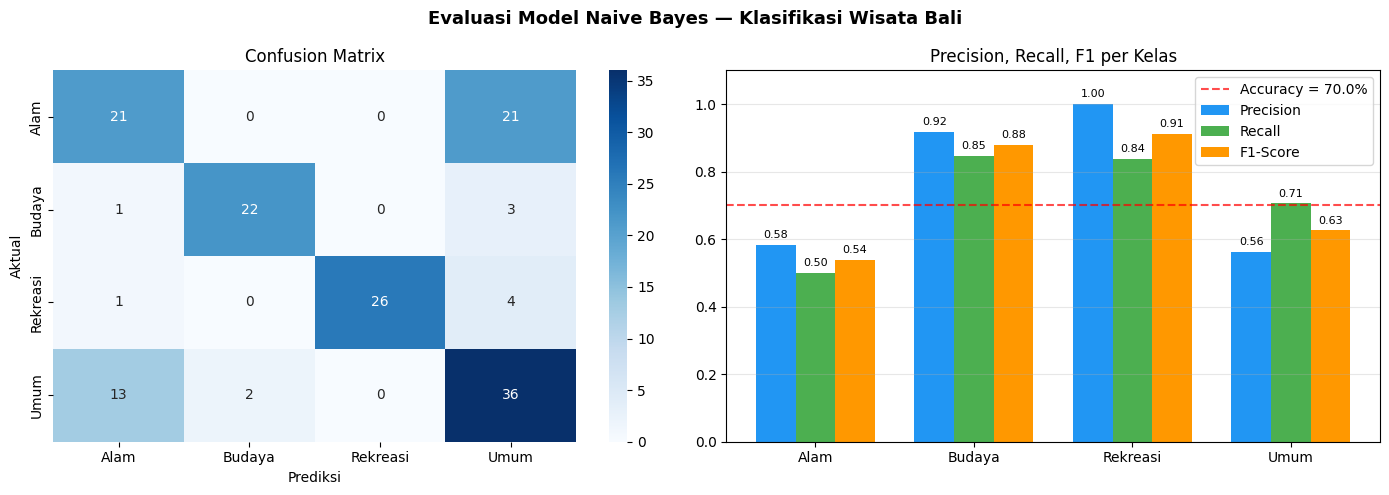


  [INFO] Grafik disimpan sebagai 'evaluasi_naive_bayes.png'


In [11]:
print("\n\n" + "=" * 65)
print("   BAGIAN 7 — EVALUASI AKURASI MODEL")
print("=" * 65)

def predict_all(model, df_test):
    """Prediksi seluruh data uji."""
    preds = []
    for _, row in df_test.iterrows():
        # Handle unseen kabupaten (gunakan Laplace — nilai sudah ada karena fit dari train)
        kab = row['kabupaten_kota']
        if kab not in model['likelihood']['kabupaten_kota']:
            kab = list(FEATURES['kabupaten_kota'])[0]  # fallback
        pred = predict_one(model, kab,
                           row['rating_range'], row['nama_hint'], verbose=False)
        preds.append(pred)
    return preds

y_true = df_test['kategori'].tolist()
y_pred = predict_all(model, df_test)

# --- Hitung metrik per kelas ---
def hitung_metrik(y_true, y_pred, classes):
    """Hitung accuracy, precision, recall, F1 per kelas."""
    n = len(y_true)
    total_correct = sum(t == p for t, p in zip(y_true, y_pred))
    accuracy = total_correct / n

    hasil = {}
    for cls in classes:
        TP = sum((t == cls and p == cls) for t, p in zip(y_true, y_pred))
        FP = sum((t != cls and p == cls) for t, p in zip(y_true, y_pred))
        FN = sum((t == cls and p != cls) for t, p in zip(y_true, y_pred))
        TN = sum((t != cls and p != cls) for t, p in zip(y_true, y_pred))

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
        hasil[cls] = {'TP':TP,'FP':FP,'FN':FN,'TN':TN,
                      'precision':precision,'recall':recall,'f1':f1}
    return accuracy, hasil

accuracy, metrik = hitung_metrik(y_true, y_pred, CLASSES)

print(f"\n  ═══════════════════════════════════════════════")
print(f"  AKURASI KESELURUHAN (Naive Bayes): {accuracy*100:.2f}%")
print(f"  ═══════════════════════════════════════════════")
print(f"  (Data uji: {len(y_test := y_true)} sampel)")

print("\n  Metrik per kelas:")
tabel_metrik = []
for cls in CLASSES:
    m = metrik[cls]
    tabel_metrik.append([
        cls, m['TP'], m['FP'], m['FN'],
        f"{m['precision']*100:.2f}%",
        f"{m['recall']*100:.2f}%",
        f"{m['f1']:.4f}"
    ])
print(tabulate(tabel_metrik,
               headers=["Kelas","TP","FP","FN","Precision","Recall","F1-Score"],
               tablefmt='grid'))

# Macro average
macro_prec = np.mean([metrik[c]['precision'] for c in CLASSES])
macro_rec  = np.mean([metrik[c]['recall']    for c in CLASSES])
macro_f1   = np.mean([metrik[c]['f1']        for c in CLASSES])
print(f"\n  Macro Average — Precision: {macro_prec*100:.2f}%  "
      f"Recall: {macro_rec*100:.2f}%  F1: {macro_f1:.4f}")


# --- Confusion Matrix ---
print("\n  Confusion Matrix (baris=aktual, kolom=prediksi):")
def confusion_matrix(y_true, y_pred, classes):
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    cls_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        cm[cls_idx[t]][cls_idx[p]] += 1
    return cm

cm = confusion_matrix(y_true, y_pred, CLASSES)
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
print(tabulate(cm_df, headers='keys', tablefmt='grid'))


# --- Visualisasi ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluasi Model Naive Bayes — Klasifikasi Wisata Bali",
             fontsize=13, fontweight='bold')

# Plot 1: Confusion Matrix heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Prediksi')
ax1.set_ylabel('Aktual')

# Plot 2: Metrik per kelas
ax2 = axes[1]
x    = np.arange(len(CLASSES))
w    = 0.25
prec = [metrik[c]['precision'] for c in CLASSES]
rec  = [metrik[c]['recall']    for c in CLASSES]
f1s  = [metrik[c]['f1']        for c in CLASSES]
ax2.bar(x - w,   prec, w, label='Precision', color='#2196F3')
ax2.bar(x,       rec,  w, label='Recall',    color='#4CAF50')
ax2.bar(x + w,   f1s,  w, label='F1-Score',  color='#FF9800')
ax2.set_xticks(x)
ax2.set_xticklabels(CLASSES)
ax2.set_ylim(0, 1.1)
ax2.set_title('Precision, Recall, F1 per Kelas')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for i, (p, r, f) in enumerate(zip(prec, rec, f1s)):
    ax2.text(i-w,   p+0.02, f"{p:.2f}", ha='center', fontsize=8)
    ax2.text(i,     r+0.02, f"{r:.2f}", ha='center', fontsize=8)
    ax2.text(i+w,   f+0.02, f"{f:.2f}", ha='center', fontsize=8)

# Tambahkan teks akurasi keseluruhan
ax2.axhline(accuracy, color='red', linestyle='--', alpha=0.7,
            label=f'Accuracy = {accuracy*100:.1f}%')
ax2.legend()

plt.tight_layout()
plt.savefig('evaluasi_naive_bayes.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n  [INFO] Grafik disimpan sebagai 'evaluasi_naive_bayes.png'")


# BAGIAN 8: RINGKASAN HASIL

In [13]:
print("\n\n" + "=" * 65)
print("   BAGIAN 8 — RINGKASAN HASIL NAIVE BAYES")
print("=" * 65)

print(f"""
  Dataset          : {DATASET_PATH}
  Total data bersih: {len(df)} tempat wisata
  Data latih       : {len(df_train)} sampel (80%)
  Data uji         : {len(df_test)} sampel (20%)

  Fitur (Evidence):
    E1 — kabupaten_kota (9 kategori lokasi)
    E2 — rating_range   (rendah / sedang / tinggi)
    E3 — nama_hint      (alam / budaya / rekreasi / no_hint)

  Target: kategori wisata (Alam / Budaya / Rekreasi / Umum)

  ┌──────────────────────────────────────────────┐
  │  AKURASI NAIVE BAYES : {accuracy*100:>6.2f}%               │
  │  Macro Precision     : {macro_prec*100:>6.2f}%               │
  │  Macro Recall        : {macro_rec*100:>6.2f}%               │
  │  Macro F1-Score      : {macro_f1:>6.4f}                │
  └──────────────────────────────────────────────┘

  Catatan:
  • Kelas dengan akurasi tertinggi: {max(CLASSES, key=lambda c: metrik[c]['f1'])}
    (F1 = {max(metrik[c]['f1'] for c in CLASSES):.4f})
  • Kelas dengan akurasi terendah: {min(CLASSES, key=lambda c: metrik[c]['f1'])}
    (F1 = {min(metrik[c]['f1'] for c in CLASSES):.4f})
  • Laplace Smoothing α = {ALPHA}
    digunakan untuk menghindari probabilitas nol pada data uji.
""")

print("[✓] Program Teorema Bayes selesai dijalankan.")
print(f"    Akurasi Naive Bayes: {accuracy*100:.2f}%")





   BAGIAN 8 — RINGKASAN HASIL NAIVE BAYES

  Dataset          : dataset_tempat_wisata_bali.xlsx
  Total data bersih: 747 tempat wisata
  Data latih       : 597 sampel (80%)
  Data uji         : 150 sampel (20%)
 
  Fitur (Evidence):
    E1 — kabupaten_kota (9 kategori lokasi)
    E2 — rating_range   (rendah / sedang / tinggi)
    E3 — nama_hint      (alam / budaya / rekreasi / no_hint)
 
  Target: kategori wisata (Alam / Budaya / Rekreasi / Umum)
 
  ┌──────────────────────────────────────────────┐
  │  AKURASI NAIVE BAYES :  70.00%               │
  │  Macro Precision     :  76.56%               │
  │  Macro Recall        :  72.27%               │
  │  Macro F1-Score      : 0.7392                │
  └──────────────────────────────────────────────┘
 
  Catatan:
  • Kelas dengan akurasi tertinggi: Rekreasi
    (F1 = 0.9123)
  • Kelas dengan akurasi terendah: Alam
    (F1 = 0.5385)
  • Laplace Smoothing α = 1
    digunakan untuk menghindari probabilitas nol pada data uji.

[✓] Program 